<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/thermoml_model_accuracy_and_parameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ThermoML model accuracy and parameter tuning with NeqSim

This notebook turns two public ThermoML records into reproducible model tests:

1. **physical property:** pure n-heptane liquid density over temperature and pressure, tuning the constant Péneloux volume-correction coordinate; and
2. **phase equilibrium:** CO$_2$ + n-hexane pressure-composition VLE, tuning a classic Peng–Robinson binary interaction parameter $k_{ij}$.

[ThermoMLPy](https://github.com/snaserib/ThermoMLPy) provides the XML-to-table bridge. Current NeqSim `master` provides the thermodynamic calculations. SciPy supplies bounded least squares. Deterministic held-out points reveal whether a lower calibration error also improves prediction.

**Learning objectives.** After running the notebook, you can retrieve a DOI-specific ThermoML record, audit its provenance and units, map its compounds to NeqSim, define a residual function, fit bounded model parameters, compare baseline/tuned train and validation errors, and recognize parameter or model-form limitations.

## 1. Scope, data rights, and engineering boundary

The calculations use DOI-specific XML records fetched at runtime from the [NIST ThermoML Archive](https://trc.nist.gov/ThermoML.html). The notebook does not redistribute the records. ThermoMLPy is MIT-licensed; rights and citation requirements for the experimental data remain separate.

| Case | ThermoML record | NeqSim model | Fitted coordinate |
|---|---|---|---|
| Density | [10.1016/j.jct.2016.04.014](https://trc.nist.gov/ThermoML/10.1016/j.jct.2016.04.014.xml), pure n-heptane section | Peng–Robinson, classic mixing | Constant Péneloux volume correction $c$ |
| VLE | [10.1016/j.jct.2015.10.009](https://trc.nist.gov/ThermoML/10.1016/j.jct.2015.10.009.xml), CO$_2$ + n-hexane sections | Peng–Robinson, classic mixing | Symmetric CO$_2$/n-hexane $k_{ij}$ |

These are model-development demonstrations, not property-data certification or design assurance. Before engineering use, confirm the experimental record, units, uncertainty definition, model family, parameter transferability, phase identification, and the intended operating envelope.

## 2. Reproducible source setup

The released `neqsim` Python package supplies the JPype bridge. The next cell builds current `equinor/neqsim` `master`, records its resolved commit and JAR SHA-256, and verifies the loaded Java class location before any calculation. ThermoMLPy is checked out at the immutable commit used to develop this tutorial.

For local validation, `NEQSIM_SOURCE_ROOT`, `NEQSIM_SOURCE_JAR`, and `THERMOMLPY_SOURCE_ROOT` can point to checked-out sources. Colab follows the clone-and-build path.

In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


try:
    neqsim_bridge_version = version("neqsim")
except PackageNotFoundError:
    neqsim_bridge_version = None

if neqsim_bridge_version != "3.16.0":
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            "neqsim==3.16.0",
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
using_local_neqsim = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_neqsim:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in (
                    "sources",
                    "javadoc",
                    "tests",
                    "original",
                )
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(
        jar_candidates,
        key=lambda path: len(path.name),
    )[0]

THERMOMLPY_COMMIT = "4d4d4f17175e91bb42278fb15a3330f9b2bbe34f"
THERMOMLPY_REPOSITORY = "https://github.com/snaserib/ThermoMLPy.git"
THERMOMLPY_ROOT = Path(
    os.environ.get("THERMOMLPY_SOURCE_ROOT", "/content/ThermoMLPy")
).resolve()
using_local_thermomlpy = "THERMOMLPY_SOURCE_ROOT" in os.environ
if not (THERMOMLPY_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            THERMOMLPY_REPOSITORY,
            str(THERMOMLPY_ROOT),
        ],
        check=True,
    )
elif not using_local_thermomlpy:
    subprocess.run(
        [
            "git",
            "-C",
            str(THERMOMLPY_ROOT),
            "fetch",
            "--quiet",
            "origin",
            THERMOMLPY_COMMIT,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(THERMOMLPY_ROOT),
            "checkout",
            "--quiet",
            THERMOMLPY_COMMIT,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(THERMOMLPY_ROOT),
            "checkout",
            "--quiet",
            THERMOMLPY_COMMIT,
        ],
        check=True,
    )

resolved_thermomlpy_commit = subprocess.check_output(
    ["git", "-C", str(THERMOMLPY_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()
assert resolved_thermomlpy_commit == THERMOMLPY_COMMIT
sys.path.insert(0, str(THERMOMLPY_ROOT))

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the source JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemPrEos")
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION

print(f"NeqSim bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded SystemPrEos from: {LOADED_JAR_LOCATION}")
print(f"ThermoMLPy source commit: {resolved_thermomlpy_commit}")
print(f"Python runtime: {platform.python_version()}")

NeqSim bridge: 3.16.0
NeqSim source ref: master
NeqSim source commit: 641c871677a02a25b0c62c2278b8d286d20e11a4
NeqSim source JAR SHA-256: 66cdc4057f24723c452a11aa9df212f2fd595ba11c7ca3a7439e310ae729f8f3
Loaded SystemPrEos from: file:/workspace/scratch/fb4b581e4b35/neqsim-master/target/neqsim-3.16.0.jar
ThermoMLPy source commit: 4d4d4f17175e91bb42278fb15a3330f9b2bbe34f
Python runtime: 3.12.13


In [2]:
from importlib.metadata import version
import inspect
import logging
import xml.etree.ElementTree as ET
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from neqsim import jneqsim


logging.disable(logging.WARNING)
from thermomlpy.parsers.thermoml_parser import ThermoMLParser
logging.disable(logging.NOTSET)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 6)
pd.set_option("display.max_columns", None)

SystemPrEos = jneqsim.thermo.system.SystemPrEos
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)

thermomlpy_parser_source = Path(
    inspect.getfile(ThermoMLParser)
).resolve()
assert THERMOMLPY_ROOT in thermomlpy_parser_source.parents

runtime_versions = pd.DataFrame(
    {
        "Package": [
            "neqsim bridge",
            "ThermoMLPy source",
            "SciPy",
            "NumPy",
            "pandas",
            "Matplotlib",
        ],
        "Version or commit": [
            version("neqsim"),
            THERMOMLPY_COMMIT[:12],
            version("scipy"),
            version("numpy"),
            version("pandas"),
            version("matplotlib"),
        ],
    }
)
runtime_versions

,Package,Version or commit
0,neqsim bridge,3.16.0
1,ThermoMLPy source,4d4d4f17175e
2,SciPy,1.18.0
3,NumPy,2.5.1
4,pandas,3.0.5
5,Matplotlib,3.11.1


## 3. Retrieve and parse two DOI-specific ThermoML records

Downloading two records instead of the full archive keeps the tutorial small and traceable. Known SHA-256 digests make silent data changes visible. Direct parser use does not require ThermoMLPy's optional RDKit chemistry helpers.

In [3]:
DATA_ROOT = Path(
    os.environ.get("THERMOML_DATA_ROOT", "/tmp/thermoml-model-test")
).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "density": {
        "url": (
            "https://trc.nist.gov/ThermoML/"
            "10.1016/j.jct.2016.04.014.xml"
        ),
        "sha256": (
            "5b4376820a9b67b18b10d0a03256b174"
            "828d85eda54fb2abca5c0fd93d16fc1c"
        ),
        "override": "THERMOML_DENSITY_XML",
    },
    "vle": {
        "url": (
            "https://trc.nist.gov/ThermoML/"
            "10.1016/j.jct.2015.10.009.xml"
        ),
        "sha256": (
            "0bc7e50a7714596265315396a19df7ccb"
            "ec4072f107570362ab1e1d250c5b55f"
        ),
        "override": "THERMOML_VLE_XML",
    },
}

data_paths = {}
data_audit_rows = []
for name, metadata in DATASETS.items():
    override = os.environ.get(metadata["override"])
    if override:
        path = Path(override).resolve()
    else:
        path = DATA_ROOT / f"{name}.xml"
        if not path.is_file():
            urlretrieve(metadata["url"], path)
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    assert digest == metadata["sha256"]
    data_paths[name] = path
    data_audit_rows.append(
        {
            "Record": name,
            "Bytes": path.stat().st_size,
            "SHA-256": digest,
            "Source": metadata["url"],
        }
    )

pd.DataFrame(data_audit_rows)

,Record,Bytes,SHA-256,Source
0,density,984336,5b4376820a9b67b18b10d0a03256b174828d85eda54fb2...,https://trc.nist.gov/ThermoML/10.1016/j.jct.20...
1,vle,173203,0bc7e50a7714596265315396a19df7ccbec4072f107570...,https://trc.nist.gov/ThermoML/10.1016/j.jct.20...


In [4]:
density_raw = pd.DataFrame(
    ThermoMLParser(data_paths["density"]).parse()
)
vle_raw = pd.DataFrame(ThermoMLParser(data_paths["vle"]).parse())

record_audit = pd.DataFrame(
    [
        {
            "Case": "density",
            "Rows parsed": len(density_raw),
            "DOI": density_raw["citation_doi"].iloc[0],
            "Year": density_raw["citation_year"].iloc[0],
            "Title": density_raw["citation_title"].iloc[0],
        },
        {
            "Case": "VLE",
            "Rows parsed": len(vle_raw),
            "DOI": vle_raw["citation_doi"].iloc[0],
            "Year": vle_raw["citation_year"].iloc[0],
            "Title": vle_raw["citation_title"].iloc[0],
        },
    ]
)
record_audit

,Case,Rows parsed,DOI,Year,Title
0,density,1291,10.1016/j.jct.2016.04.014,2016,Densities and derived thermodynamic properties...
1,VLE,215,10.1016/j.jct.2015.10.009,2016,Isothermal (vapour + liquid) equilibrium data ...


In [5]:
section_audit = pd.concat(
    [
        density_raw.groupby(
            ["section_index", "components"],
            dropna=False,
        ).size().rename("Rows").reset_index().assign(Record="density"),
        vle_raw.groupby(
            ["section_index", "components"],
            dropna=False,
        ).size().rename("Rows").reset_index().assign(Record="VLE"),
    ],
    ignore_index=True,
)
section_audit[
    ["Record", "section_index", "components", "Rows"]
].head(18)

,Record,section_index,components,Rows
0,density,1,heptane,227
1,density,2,octane,227
2,density,3,ethanol,222
3,density,4,octane__heptane,207
4,density,5,ethanol__heptane,204
5,density,6,ethanol__octane,204
6,VLE,1,carbon dioxide,7
7,VLE,2,trifluoromethane,8
8,VLE,3,hexane,1
9,VLE,4,hexane,1


### Component mapping and a parser-provenance guard

ThermoML names are not assumed to equal NeqSim database names. This tutorial maps `heptane` to `n-heptane`, `hexane` to `n-hexane`, and `carbon dioxide` to `CO2` explicitly.

ThermoMLPy commit `4d4d4f1` labels the section-6 gas composition as `Mole fraction 1`. For this record, that positional label is misleading: the XML property target is organization number 1, which maps to carbon dioxide, whereas the section compound display order starts with hexane. [ThermoMLPy issue #1](https://github.com/snaserib/ThermoMLPy/issues/1) contains the minimal reproducer. The next cell verifies the XML relationship before renaming the column; it does not silently guess.

In [6]:
COMPONENT_MAP = {
    "heptane": "n-heptane",
    "hexane": "n-hexane",
    "carbon dioxide": "CO2",
}

root = ET.parse(data_paths["vle"]).getroot()
namespace_uri = root.tag.split("}")[0].strip("{")
ns = {"t": namespace_uri}

org_to_common_name = {}
for compound in root.findall(".//t:Compound", ns):
    org_number = compound.findtext("t:RegNum/t:nOrgNum", namespaces=ns)
    common_name = compound.findtext("t:sCommonName", namespaces=ns)
    org_to_common_name[org_number] = common_name

vle_sections = root.findall(".//t:PureOrMixtureData", ns)
section_six_property = vle_sections[5].find("t:Property", ns)
nested_target = section_six_property.findtext(
    "t:Property-MethodID/t:RegNum/t:nOrgNum",
    namespaces=ns,
)
target_phase = section_six_property.findtext(
    "t:PropPhaseID/t:ePropPhase",
    namespaces=ns,
)
target_common_name = org_to_common_name[nested_target]

assert target_phase == "Gas"
assert target_common_name == "carbon dioxide"
assert "Mole fraction 1" in vle_raw.columns

mapping_audit = pd.DataFrame(
    [
        {
            "ThermoML name": source,
            "NeqSim name": target,
            "Use": "density" if source == "heptane" else "VLE",
        }
        for source, target in COMPONENT_MAP.items()
    ]
)
mapping_audit["Parser guard"] = [
    "direct section name",
    "direct section name",
    f"nested nOrgNum={nested_target}, phase={target_phase}",
]
mapping_audit

,ThermoML name,NeqSim name,Use,Parser guard
0,heptane,n-heptane,density,direct section name
1,hexane,n-hexane,VLE,direct section name
2,carbon dioxide,CO2,VLE,"nested nOrgNum=1, phase=Gas"


## 4. Calibration and validation formulation

For an experimental response $z_n^{\mathrm{exp}}$ and model response $z_n^{\mathrm{model}}(\boldsymbol{\theta})$, both fits minimize relative residuals on deterministic calibration subsets:

$$r_n(\boldsymbol{\theta})=\frac{z_n^{\mathrm{model}}(\boldsymbol{\theta})-z_n^{\mathrm{exp}}}{z_n^{\mathrm{exp}}}$$

Relative residuals prevent the high end of a response range from dominating solely through units. Reported uncertainties are retained for diagnostics rather than used as inverse-variance weights because the two records do not establish a complete covariance model.

The principal summary statistic is absolute average relative deviation:

$$\mathrm{AARD}(\%)=\frac{100}{N}\sum_{n=1}^{N}\left|r_n\right|$$

The density split holds out every fifth measurement index; the VLE split holds out every fourth. These interleaved splits test interpolation within the measured envelope, not extrapolation or cross-source transferability.

NeqSim's legacy physical-property correction uses the internal cubic-EOS molar-volume unit $10^{-5}\,\mathrm{m^3\,mol^{-1}}$:

$$v_{\mathrm{corr}}=v_{\mathrm{EOS}}-\sum_i x_i\left[c_i+c_{T,i}(T-288.15\,\mathrm{K})\right]$$

Here only the constant $c$ for pure n-heptane is fitted; its database temperature coefficient is zero. For VLE, classic quadratic mixing uses:

$$a_m=\sum_i\sum_j x_i x_j\sqrt{a_i a_j}(1-k_{ij})$$

In [7]:
def error_metrics(experimental, calculated):
    experimental = np.asarray(experimental, dtype=float)
    calculated = np.asarray(calculated, dtype=float)
    error = calculated - experimental
    return {
        "AARD, %": 100.0 * np.mean(np.abs(error / experimental)),
        "RMSE": np.sqrt(np.mean(error**2)),
        "Bias": np.mean(error),
        "MAE": np.mean(np.abs(error)),
    }


def split_label(frame, modulus):
    return np.where(
        frame["measurement_index"].to_numpy() % modulus == 0,
        "Validation",
        "Calibration",
    )

## 5. Physical-property test: pure n-heptane density

Section 1 contains 227 density measurements from 288.15 to 413.15 K and approximately 0.1 to 60 MPa. Each evaluation builds a fresh pure-fluid Peng–Robinson system, applies the candidate constant volume correction, performs a TP flash, initializes physical properties, and reads density in `kg/m3`.

In [8]:
density = density_raw.loc[
    (density_raw["section_index"] == 1)
    & density_raw["Mass density, kg/m3"].notna(),
    [
        "measurement_index",
        "Temperature, K",
        "Pressure, kPa",
        "Mass density, kg/m3",
        "Mass density, kg/m3_uncertainty",
    ],
].copy()
density = density.rename(
    columns={
        "Temperature, K": "temperature_k",
        "Pressure, kPa": "pressure_kpa",
        "Mass density, kg/m3": "density_exp_kg_m3",
        "Mass density, kg/m3_uncertainty": "density_u_kg_m3",
    }
)
density["Split"] = split_label(density, modulus=5)

assert len(density) == 227
assert set(density["Split"]) == {"Calibration", "Validation"}
density.groupby("Split").agg(
    Points=("measurement_index", "size"),
    T_min_K=("temperature_k", "min"),
    T_max_K=("temperature_k", "max"),
    P_min_kPa=("pressure_kpa", "min"),
    P_max_kPa=("pressure_kpa", "max"),
)

,Points,T_min_K,T_max_K,P_min_kPa,P_max_kPa
Split,,,,,
Calibration,182,288.15,413.15,100.0,60000.0
Validation,45,288.15,413.15,100.0,60000.0


In [9]:
def make_heptane_system():
    system = SystemPrEos(298.15, 1.01325)
    system.addComponent(COMPONENT_MAP["heptane"], 1.0)
    system.setMixingRule("classic")
    return system


def density_prediction(temperature_k, pressure_kpa, correction):
    system = SystemPrEos(
        float(temperature_k),
        float(pressure_kpa) / 100.0,
    )
    system.addComponent(COMPONENT_MAP["heptane"], 1.0)
    system.setMixingRule("classic")
    system.setComponentVolumeCorrection(
        COMPONENT_MAP["heptane"],
        float(correction),
    )
    operations = ThermodynamicOperations(system)
    operations.TPflash()
    system.initProperties()
    return float(system.getDensity("kg/m3"))


def predict_density_frame(frame, correction):
    return np.array(
        [
            density_prediction(row.temperature_k, row.pressure_kpa, correction)
            for row in frame.itertuples(index=False)
        ]
    )


heptane_system = make_heptane_system()
default_volume_correction = float(
    heptane_system.getComponent(
        COMPONENT_MAP["heptane"]
    ).getVolumeCorrection()
)
volume_correction_t = float(
    heptane_system.getComponent(
        COMPONENT_MAP["heptane"]
    ).getVolumeCorrectionT()
)
assert volume_correction_t == 0.0
print(
    "Database constant volume correction: "
    f"{default_volume_correction:.8f} internal units"
)
print(
    "Equivalent constant correction: "
    f"{10.0 * default_volume_correction:.6f} cm3/mol"
)

Database constant volume correction: -0.01651583 internal units
Equivalent constant correction: -0.165158 cm3/mol


In [10]:
density_calibration = density["Split"] == "Calibration"


def density_residual(parameter):
    predicted = predict_density_frame(
        density.loc[density_calibration],
        correction=parameter[0],
    )
    experimental = density.loc[
        density_calibration,
        "density_exp_kg_m3",
    ].to_numpy()
    return (predicted - experimental) / experimental


density_fit = least_squares(
    density_residual,
    x0=[default_volume_correction],
    bounds=([-0.05], [0.15]),
    xtol=1e-10,
    ftol=1e-10,
    gtol=1e-10,
)
fitted_volume_correction = float(density_fit.x[0])
assert density_fit.success
assert -0.05 < fitted_volume_correction < 0.15

density_parameter_table = pd.DataFrame(
    {
        "Coordinate": ["Database", "Fitted"],
        "c, internal units": [
            default_volume_correction,
            fitted_volume_correction,
        ],
        "c, cm3/mol": [
            10.0 * default_volume_correction,
            10.0 * fitted_volume_correction,
        ],
        "Function evaluations": [0, density_fit.nfev],
    }
)
density_parameter_table

,Coordinate,"c, internal units","c, cm3/mol",Function evaluations
0,Database,-0.016516,-0.165158,0
1,Fitted,0.019606,0.196058,6


In [11]:
density["density_database_kg_m3"] = predict_density_frame(
    density,
    correction=default_volume_correction,
)
density["density_tuned_kg_m3"] = predict_density_frame(
    density,
    correction=fitted_volume_correction,
)

density_metric_rows = []
for split in ["Calibration", "Validation"]:
    selected = density["Split"] == split
    for model, column in [
        ("Database c", "density_database_kg_m3"),
        ("Tuned c", "density_tuned_kg_m3"),
    ]:
        metrics = error_metrics(
            density.loc[selected, "density_exp_kg_m3"],
            density.loc[selected, column],
        )
        density_metric_rows.append(
            {
                "Split": split,
                "Model": model,
                "AARD, %": metrics["AARD, %"],
                "RMSE, kg/m3": metrics["RMSE"],
                "Bias, kg/m3": metrics["Bias"],
            }
        )

density_metrics = pd.DataFrame(density_metric_rows)
density_metrics

,Split,Model,"AARD, %","RMSE, kg/m3","Bias, kg/m3"
0,Calibration,Database c,0.841477,6.699910,-1.769584
1,Calibration,Tuned c,0.777187,6.399373,-0.123018
2,Validation,Database c,0.828451,6.573749,-1.923743
3,Validation,Tuned c,0.760098,6.234723,-0.283270


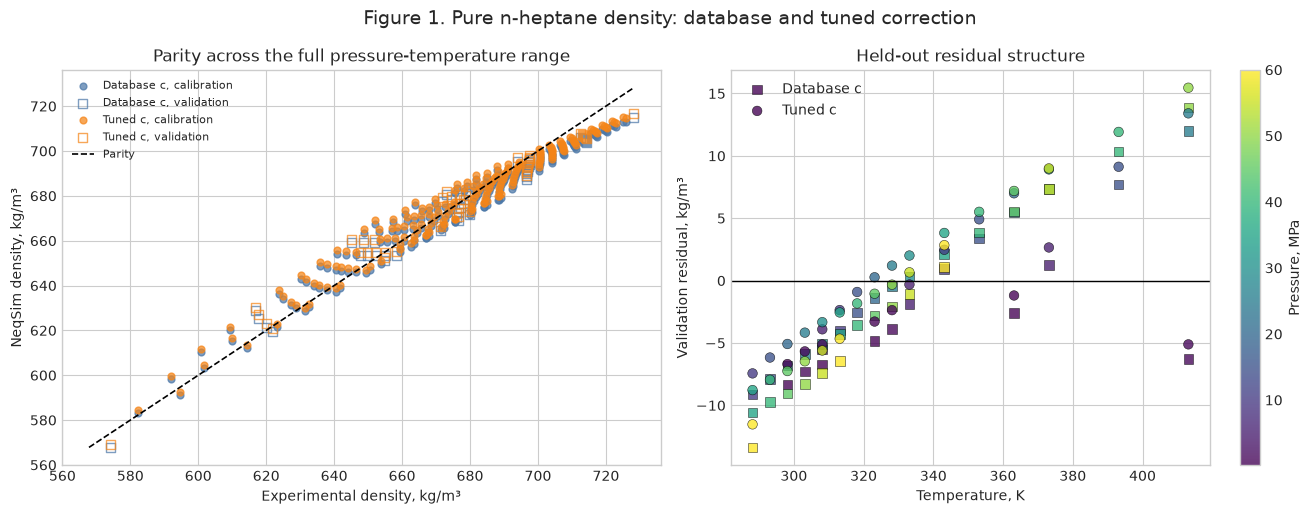

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

colors = {"Database c": "#4C78A8", "Tuned c": "#F58518"}
columns = {
    "Database c": "density_database_kg_m3",
    "Tuned c": "density_tuned_kg_m3",
}
for model, column in columns.items():
    for split, marker, face in [
        ("Calibration", "o", colors[model]),
        ("Validation", "s", "none"),
    ]:
        selected = density["Split"] == split
        axes[0].scatter(
            density.loc[selected, "density_exp_kg_m3"],
            density.loc[selected, column],
            s=24 if split == "Calibration" else 42,
            marker=marker,
            facecolors=face,
            edgecolors=colors[model],
            linewidths=1.0,
            alpha=0.72,
            label=f"{model}, {split.lower()}",
        )

parity_min = density[
    [
        "density_exp_kg_m3",
        "density_database_kg_m3",
        "density_tuned_kg_m3",
    ]
].min().min()
parity_max = density[
    [
        "density_exp_kg_m3",
        "density_database_kg_m3",
        "density_tuned_kg_m3",
    ]
].max().max()
axes[0].plot(
    [parity_min, parity_max],
    [parity_min, parity_max],
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="Parity",
)
axes[0].set_xlabel("Experimental density, kg/m³")
axes[0].set_ylabel("NeqSim density, kg/m³")
axes[0].set_title("Parity across the full pressure-temperature range")
axes[0].legend(fontsize=8)

for model, column in columns.items():
    residual = density[column] - density["density_exp_kg_m3"]
    selected = density["Split"] == "Validation"
    scatter = axes[1].scatter(
        density.loc[selected, "temperature_k"],
        residual[selected],
        c=density.loc[selected, "pressure_kpa"] / 1000.0,
        cmap="viridis",
        marker="s" if model == "Database c" else "o",
        s=48,
        alpha=0.78,
        edgecolors="black",
        linewidths=0.4,
        label=model,
    )
axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].set_xlabel("Temperature, K")
axes[1].set_ylabel("Validation residual, kg/m³")
axes[1].set_title("Held-out residual structure")
axes[1].legend()
colorbar = fig.colorbar(scatter, ax=axes[1])
colorbar.set_label("Pressure, MPa")

fig.suptitle(
    "Figure 1. Pure n-heptane density: database and tuned correction",
    fontsize=14,
)
fig.tight_layout()
plt.show()

**Figure 1 discussion.** The tuned constant moves the held-out AARD from about 0.828% to 0.760% and lowers held-out RMSE, so the improvement is not confined to the calibration rows. The residual cloud nevertheless retains temperature/pressure structure and remains larger than many reported density uncertainties (0.25–2.9 kg/m$^3$). Mechanistically, one constant volume translation can shift liquid molar volume but cannot repair all temperature- and pressure-dependent departures of the PR model. For engineering work, treat this fit as a local volumetric adjustment, inspect structured residuals, and prefer a richer density model or temperature dependence before extrapolation.

## 6. VLE test: CO$_2$ + n-hexane

ThermoML sections 5 and 6 contain 35 matched equilibrium points near 303.1, 313.1, and 323.1 K. Section 5 provides bubble pressure and liquid CO$_2$ mole fraction; section 6 provides the matched gas CO$_2$ mole fraction after the provenance guard above.

The demonstration fits one symmetric classic-PR $k_{ij}$ to **pressure only**. Gas composition remains an independent test response. Three coordinates are compared: $k_{ij}=0$, NeqSim's database value, and the pressure-fitted value.

In [13]:
vle_liquid = vle_raw.loc[
    vle_raw["section_index"] == 5,
    [
        "measurement_index",
        "Temperature, K",
        "Vapor or sublimation pressure, kPa",
        "Vapor or sublimation pressure, kPa_uncertainty",
        "Mole fraction 2",
    ],
].copy()
vle_liquid = vle_liquid.rename(
    columns={
        "Temperature, K": "temperature_k",
        "Vapor or sublimation pressure, kPa": "pressure_exp_kpa",
        "Vapor or sublimation pressure, kPa_uncertainty": (
            "pressure_u_kpa"
        ),
        "Mole fraction 2": "x_co2_exp",
    }
)
vle_gas = vle_raw.loc[
    vle_raw["section_index"] == 6,
    [
        "measurement_index",
        "Mole fraction 1",
        "Mole fraction 1_uncertainty",
    ],
].copy()
vle_gas = vle_gas.rename(
    columns={
        "Mole fraction 1": "y_co2_exp",
        "Mole fraction 1_uncertainty": "y_co2_u",
    }
)
vle = vle_liquid.merge(
    vle_gas,
    on="measurement_index",
    validate="one_to_one",
)
vle["temperature_group_k"] = vle["temperature_k"].round().astype(int)
vle["Split"] = split_label(vle, modulus=4)

assert len(vle) == 35
assert set(vle["temperature_group_k"]) == {303, 313, 323}
assert vle[["x_co2_exp", "y_co2_exp"]].ge(0.0).all().all()
assert vle[["x_co2_exp", "y_co2_exp"]].le(1.0).all().all()
vle.groupby(["temperature_group_k", "Split"]).size().unstack(
    fill_value=0
)

Split,Calibration,Validation
temperature_group_k,,
303,9,2
313,9,3
323,9,3


In [14]:
def make_vle_system():
    system = SystemPrEos(313.15, 50.0)
    system.addComponent(COMPONENT_MAP["hexane"], 0.5)
    system.addComponent(COMPONENT_MAP["carbon dioxide"], 0.5)
    system.setMixingRule("classic")
    return system


def vle_prediction(temperature_k, x_co2, kij):
    system = SystemPrEos(float(temperature_k), 50.0)
    system.addComponent(
        COMPONENT_MAP["hexane"],
        float(1.0 - x_co2),
    )
    system.addComponent(
        COMPONENT_MAP["carbon dioxide"],
        float(x_co2),
    )
    system.setMixingRule("classic")
    system.setBinaryInteractionParameter(
        COMPONENT_MAP["hexane"],
        COMPONENT_MAP["carbon dioxide"],
        float(kij),
    )
    operations = ThermodynamicOperations(system)
    operations.bubblePointPressureFlash(False)
    pressure_kpa = float(system.getPressure("bara")) * 100.0
    y_co2 = float(
        system.getPhase("gas")
        .getComponent(COMPONENT_MAP["carbon dioxide"])
        .getx()
    )
    return pressure_kpa, y_co2


def predict_vle_frame(frame, kij):
    predictions = np.array(
        [
            vle_prediction(row.temperature_k, row.x_co2_exp, kij)
            for row in frame.itertuples(index=False)
        ]
    )
    return predictions[:, 0], predictions[:, 1]


database_vle_system = make_vle_system()
database_kij = float(
    database_vle_system.getPhase(0)
    .getMixingRule()
    .getBinaryInteractionParameter(0, 1)
)
print(f"NeqSim database k_ij: {database_kij:.8f}")

NeqSim database k_ij: 0.12000000


In [15]:
vle_calibration = vle["Split"] == "Calibration"


def vle_pressure_residual(parameter):
    pressure_predicted, _ = predict_vle_frame(
        vle.loc[vle_calibration],
        kij=parameter[0],
    )
    pressure_experimental = vle.loc[
        vle_calibration,
        "pressure_exp_kpa",
    ].to_numpy()
    return (
        pressure_predicted - pressure_experimental
    ) / pressure_experimental


vle_fit = least_squares(
    vle_pressure_residual,
    x0=[database_kij],
    bounds=([-0.10], [0.25]),
    xtol=1e-10,
    ftol=1e-10,
    gtol=1e-10,
)
fitted_kij = float(vle_fit.x[0])
assert vle_fit.success
assert -0.10 < fitted_kij < 0.25

vle_parameter_table = pd.DataFrame(
    {
        "Coordinate": ["Zero", "NeqSim database", "Pressure-fitted"],
        "k_ij": [0.0, database_kij, fitted_kij],
        "Function evaluations": [0, 0, vle_fit.nfev],
    }
)
vle_parameter_table

,Coordinate,k_ij,Function evaluations
0,Zero,0.000000,0
1,NeqSim database,0.120000,0
2,Pressure-fitted,0.120706,4


In [16]:
VLE_MODELS = {
    "Zero k_ij": 0.0,
    "Database k_ij": database_kij,
    "Fitted k_ij": fitted_kij,
}
for model, kij in VLE_MODELS.items():
    pressure_prediction, y_prediction = predict_vle_frame(vle, kij)
    slug = model.lower().replace(" ", "_")
    vle[f"pressure_{slug}_kpa"] = pressure_prediction
    vle[f"y_co2_{slug}"] = y_prediction

vle_metric_rows = []
for split in ["Calibration", "Validation"]:
    selected = vle["Split"] == split
    for model in VLE_MODELS:
        slug = model.lower().replace(" ", "_")
        pressure_metrics = error_metrics(
            vle.loc[selected, "pressure_exp_kpa"],
            vle.loc[selected, f"pressure_{slug}_kpa"],
        )
        composition_metrics = error_metrics(
            vle.loc[selected, "y_co2_exp"],
            vle.loc[selected, f"y_co2_{slug}"],
        )
        vle_metric_rows.append(
            {
                "Split": split,
                "Model": model,
                "Pressure AARD, %": pressure_metrics["AARD, %"],
                "Pressure RMSE, kPa": pressure_metrics["RMSE"],
                "y_CO2 MAE": composition_metrics["MAE"],
                "y_CO2 bias": composition_metrics["Bias"],
            }
        )

vle_metrics = pd.DataFrame(vle_metric_rows)
vle_metrics

,Split,Model,"Pressure AARD, %","Pressure RMSE, kPa",y_CO2 MAE,y_CO2 bias
0,Calibration,Zero k_ij,25.114364,1303.797701,0.007853,-0.002552
1,Calibration,Database k_ij,9.035309,1194.947681,0.014954,-0.010846
2,Calibration,Fitted k_ij,9.025942,1195.282452,0.014986,-0.010879
3,Validation,Zero k_ij,25.559324,972.004658,0.006297,-0.000137
4,Validation,Database k_ij,2.563694,102.746843,0.005179,0.001407
5,Validation,Fitted k_ij,2.607233,108.013273,0.005224,0.001397


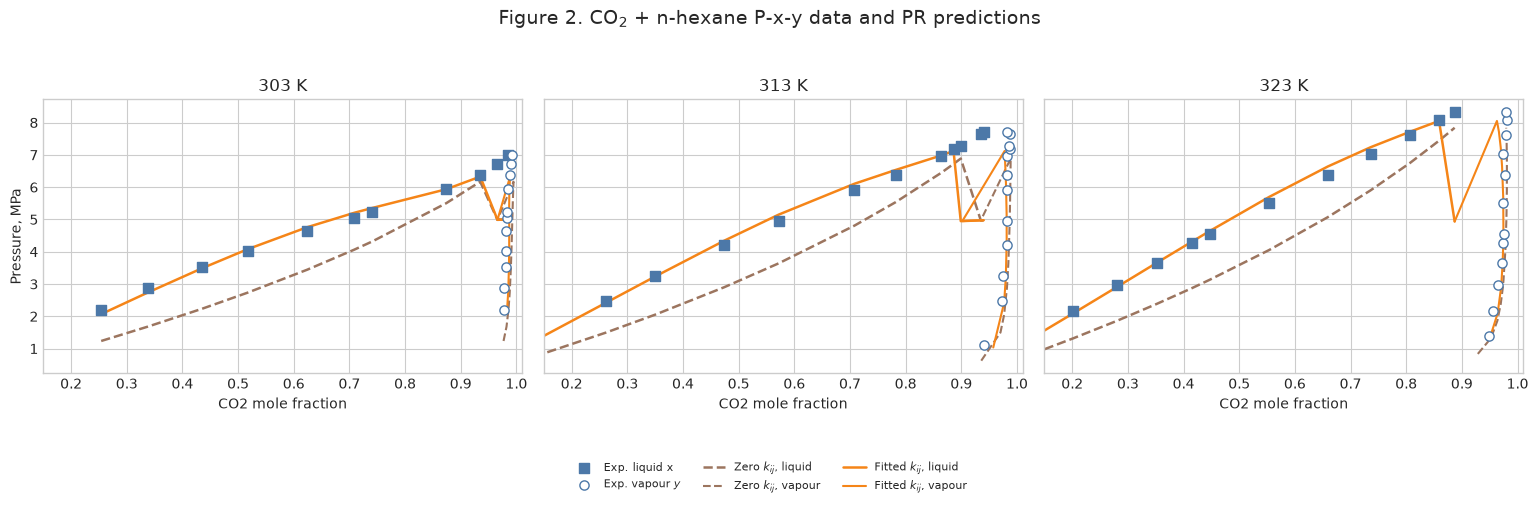

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), sharey=True)
model_styles = {
    "Zero k_ij": {"color": "#9C755F", "linestyle": "--"},
    "Fitted k_ij": {"color": "#F58518", "linestyle": "-"},
}

for axis, temperature_group in zip(axes, [303, 313, 323]):
    selected = vle["temperature_group_k"] == temperature_group
    local = vle.loc[selected].sort_values("x_co2_exp")
    axis.scatter(
        local["x_co2_exp"],
        local["pressure_exp_kpa"] / 1000.0,
        color="#4C78A8",
        marker="s",
        s=42,
        label="Exp. liquid x",
        zorder=4,
    )
    axis.scatter(
        local["y_co2_exp"],
        local["pressure_exp_kpa"] / 1000.0,
        facecolors="white",
        edgecolors="#4C78A8",
        marker="o",
        s=44,
        label="Exp. vapour $y$",
        zorder=4,
    )
    for model, style in model_styles.items():
        slug = model.lower().replace(" ", "_")
        axis.plot(
            local["x_co2_exp"],
            local[f"pressure_{slug}_kpa"] / 1000.0,
            linewidth=1.8,
            label=(
                f"{model.replace('k_ij', '$k_{ij}$')}, liquid"
            ),
            **style,
        )
        axis.plot(
            local[f"y_co2_{slug}"],
            local[f"pressure_{slug}_kpa"] / 1000.0,
            linewidth=1.5,
            label=(
                f"{model.replace('k_ij', '$k_{ij}$')}, vapour"
            ),
            **style,
        )
    axis.set_title(f"{temperature_group} K")
    axis.set_xlabel("CO2 mole fraction")
    axis.set_xlim(0.15, 1.01)

axes[0].set_ylabel("Pressure, MPa")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=8,
)
fig.suptitle(
    "Figure 2. CO$_2$ + n-hexane P-x-y data and PR predictions",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0.11, 1, 0.94])
plt.show()

**Figure 2 discussion.** Setting $k_{ij}=0$ visibly overpredicts the bubble pressures. The fitted value, about 0.1207, almost reproduces NeqSim's database value of 0.12 and cuts held-out pressure AARD from roughly 25.6% to 2.6%. That is strong evidence that the existing binary parameter carries useful pressure information. It is not evidence that a single classic-PR interaction parameter describes the entire coexistence curve: gas-composition deviations persist, and the pressure-fitted parameter can trade one response against another. The sharp fold in the joined high-CO$_2$ model points is another warning: near-critical bubble-flash roots and phase identity need continuation and stability checks before a curve is used as an envelope. The source paper used a more flexible PR/Mathias–Copeman plus Wong–Sandler/NRTL treatment; select a model family before treating $k_{ij}$ as a universal physical constant.

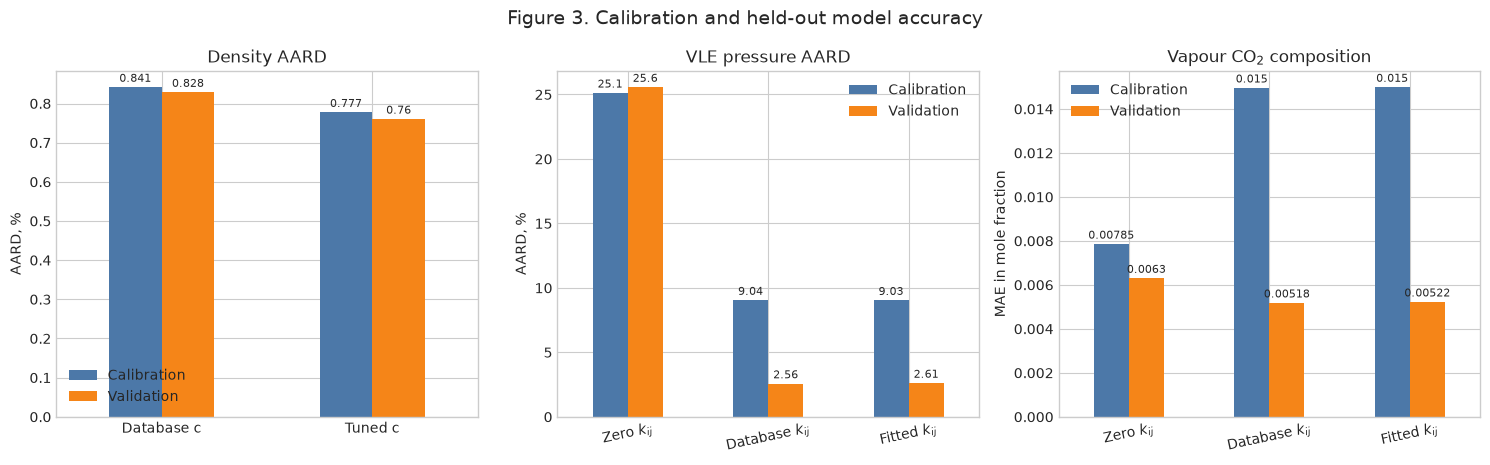

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.7))

density_pivot = density_metrics.pivot(
    index="Model",
    columns="Split",
    values="AARD, %",
).loc[["Database c", "Tuned c"]]
density_pivot.plot.bar(
    ax=axes[0],
    color=["#4C78A8", "#F58518"],
    rot=0,
)
axes[0].set_title("Density AARD")
axes[0].set_ylabel("AARD, %")
axes[0].set_xlabel("")
axes[0].legend(loc="lower left", title="")

pressure_pivot = vle_metrics.pivot(
    index="Model",
    columns="Split",
    values="Pressure AARD, %",
).loc[list(VLE_MODELS)]
pressure_pivot.plot.bar(
    ax=axes[1],
    color=["#4C78A8", "#F58518"],
    rot=12,
)
axes[1].set_title("VLE pressure AARD")
axes[1].set_ylabel("AARD, %")
axes[1].set_xlabel("")
axes[1].set_xticks(
    range(3),
    ["Zero $k_{ij}$", "Database $k_{ij}$", "Fitted $k_{ij}$"],
    rotation=12,
)

composition_pivot = vle_metrics.pivot(
    index="Model",
    columns="Split",
    values="y_CO2 MAE",
).loc[list(VLE_MODELS)]
composition_pivot.plot.bar(
    ax=axes[2],
    color=["#4C78A8", "#F58518"],
    rot=12,
)
axes[2].set_title("Vapour CO$_2$ composition")
axes[2].set_ylabel("MAE in mole fraction")
axes[2].set_xlabel("")
axes[2].set_xticks(
    range(3),
    ["Zero $k_{ij}$", "Database $k_{ij}$", "Fitted $k_{ij}$"],
    rotation=12,
)

for axis in axes:
    if axis is not axes[0]:
        axis.legend(title="")
    for container in axis.containers:
        axis.bar_label(container, fmt="%.3g", fontsize=8, padding=2)

fig.suptitle(
    "Figure 3. Calibration and held-out model accuracy",
    fontsize=14,
)
fig.tight_layout()
plt.show()

**Figure 3 discussion.** The density gain transfers to the interleaved validation subset, although the remaining error is much larger than the experimental uncertainty at many points. For VLE, the pressure-only fit improves calibration pressure AARD by only about 0.009 percentage point relative to the NeqSim database value and is slightly worse on held-out pressure. Vapour-composition MAE also does not improve. The mechanism is parameter saturation: the database $k_{ij}$ is already near the optimum of this one-parameter pressure objective, while classic PR cannot independently move pressure and both phase compositions. Keep the database value for this formulation unless a broader, independently validated regression justifies replacement.

## 7. Uncertainty-scaled diagnostics and hard validation checks

A residual divided by the reported expanded uncertainty is not automatically a statistical z-score, but it is a useful scale comparison. Large values flag model-form discrepancy, data-covariance questions, or both. The checks below also guard source provenance, finite outputs, physical compositions, split integrity, and optimizer status.

In [19]:
density["tuned_standardized_residual"] = (
    density["density_tuned_kg_m3"] - density["density_exp_kg_m3"]
) / density["density_u_kg_m3"]
fitted_pressure_column = "pressure_fitted_k_ij_kpa"
fitted_y_column = "y_co2_fitted_k_ij"
vle["pressure_standardized_residual"] = (
    vle[fitted_pressure_column] - vle["pressure_exp_kpa"]
) / vle["pressure_u_kpa"]
vle["y_standardized_residual"] = (
    vle[fitted_y_column] - vle["y_co2_exp"]
) / vle["y_co2_u"]

uncertainty_diagnostics = pd.DataFrame(
    [
        {
            "Response": "Density, tuned",
            "Split": split,
            "Mean |residual / reported u|": density.loc[
                density["Split"] == split,
                "tuned_standardized_residual",
            ].abs().mean(),
        }
        for split in ["Calibration", "Validation"]
    ]
    + [
        {
            "Response": response,
            "Split": split,
            "Mean |residual / reported u|": vle.loc[
                vle["Split"] == split,
                column,
            ].abs().mean(),
        }
        for response, column in [
            (
                "VLE pressure, fitted",
                "pressure_standardized_residual",
            ),
            ("VLE y_CO2, fitted", "y_standardized_residual"),
        ]
        for split in ["Calibration", "Validation"]
    ]
)
uncertainty_diagnostics

,Response,Split,Mean |residual / reported u|
0,"Density, tuned",Calibration,3.201968
1,"Density, tuned",Validation,2.901630
2,"VLE pressure, fitted",Calibration,17.874911
3,"VLE pressure, fitted",Validation,1.880917
4,"VLE y_CO2, fitted",Calibration,22.695154
5,"VLE y_CO2, fitted",Validation,5.418826


In [20]:
numerical_columns = [
    "density_database_kg_m3",
    "density_tuned_kg_m3",
]
assert np.isfinite(density[numerical_columns].to_numpy()).all()
assert np.isfinite(
    vle.filter(regex=r"^(pressure_|y_co2_)").to_numpy()
).all()
assert density_fit.success and vle_fit.success
assert density["Split"].value_counts().to_dict() == {
    "Calibration": 182,
    "Validation": 45,
}
assert vle["Split"].value_counts().to_dict() == {
    "Calibration": 27,
    "Validation": 8,
}
assert (
    vle.filter(regex=r"^y_co2_(zero|database|fitted)")
    .ge(0.0)
    .all()
    .all()
)
assert (
    vle.filter(regex=r"^y_co2_(zero|database|fitted)")
    .le(1.0)
    .all()
    .all()
)
assert target_common_name == "carbon dioxide"
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert resolved_thermomlpy_commit == THERMOMLPY_COMMIT

print("All source, data, optimizer, split, finiteness, and range checks passed.")

All source, data, optimizer, split, finiteness, and range checks passed.


## 8. What to reuse—and what not to conclude

**Reusable workflow**

1. Select a DOI and exact ThermoML sections; hash the XML.
2. Audit citation, compounds, units, phase labels, property targets, and uncertainties before modeling.
3. Map ThermoML names to simulator identifiers explicitly.
4. Choose the model family and fit coordinates before optimizing.
5. Bound parameters, rebuild a fresh system per state, and define a dimensionless residual.
6. Keep validation data out of the objective and report more than one response.
7. Plot residual structure and compare it with experimental uncertainty.
8. Record simulator source commit, JAR digest, parser commit, data hash, and optimizer result.

**Limits of this demonstration**

- Interleaved validation measures interpolation, not extrapolation to new temperatures, pressures, mixtures, or laboratories.
- A fitted Péneloux coordinate is model-specific and should not be transferred to another EOS without testing.
- A pressure-only $k_{ij}$ fit does not validate vapour composition. A joint objective requires deliberate weighting and may expose irreducible trade-offs.
- The optimizer covariance is not reported: residual correlation and experimental covariance are not established by these records alone.
- The VLE paper's more flexible mixing/activity treatment is a reminder that parameter tuning cannot substitute for model selection.
- ThermoMLPy issue #1 is handled by a record-specific, asserted workaround. Re-check the parser behavior before removing it.

**Exercises.** Replace the interleaved split with a leave-one-isotherm-out VLE test; compare uncertainty-weighted and relative objectives; add a second density coordinate only with a physically justified temperature dependence; or fit pressure and vapour composition jointly and plot the Pareto trade-off.

## References

- NeqSim source: [equinor/neqsim](https://github.com/equinor/neqsim)
- ThermoMLPy source: [snaserib/ThermoMLPy](https://github.com/snaserib/ThermoMLPy)
- NIST ThermoML Archive: [trc.nist.gov/ThermoML.html](https://trc.nist.gov/ThermoML.html)
- A. A. Abdussalam et al., density record: [DOI 10.1016/j.jct.2016.04.014](https://doi.org/10.1016/j.jct.2016.04.014)
- M. D. Williams-Wynn et al., VLE record: [DOI 10.1016/j.jct.2015.10.009](https://doi.org/10.1016/j.jct.2015.10.009)
- ThermoMLPy nested-property target report: [issue #1](https://github.com/snaserib/ThermoMLPy/issues/1)